# 03 · Active learning: minimise a Rosenbrock-like surface

Drive the surrogate around a bowl using `ExpectedImprovement` + `GreedyMaxMinBatchSelector`.


In [1]:
import os
os.environ["JAX_ENABLE_X64"] = "1"

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt

from jax_ldt import (
    ActiveLearner,
    HyperplaneTreeRegressor,
    ExpectedImprovement,
    GreedyMaxMinBatchSelector,
)


## Define the test objective

In [2]:
target = np.array([0.4, -0.8])

def f(X):
    return ((X - target) ** 2).sum(axis=1)

bounds = np.array([[-2.0, 2.0], [-2.0, 2.0]])


## Set up the loop

In [3]:
def factory():
    return HyperplaneTreeRegressor(
        max_depth=4, max_bins=6, min_samples_leaf=6,
        max_weight=1, num_terms=2,
    )

loop = ActiveLearner(
    model_factory=factory,
    acquisition=ExpectedImprovement(direction="min"),
    batcher=GreedyMaxMinBatchSelector(diversity_weight=0.4),
    bounds=bounds,
    batch_size=6,
    seed=11,
)

# initial random data
rng = np.random.default_rng(11)
X0 = rng.uniform(bounds[:, 0], bounds[:, 1], size=(8, 2))
loop.tell(X0, f(X0))
print(f"initial best y: {loop.y_observed.min():.3f}")


/Users/jkitchin/Dropbox/projects/jax-ldt/src/jax_ldt/hyperplanes.py:188: UserWarning: hyperplanes.symmetrize: rounded.dedup dropped 9 of 12 rows (kept 3) at tol_decimals=4. Consider increasing tol_decimals to preserve distinct directions.
  LCs_arr = symmetrize(LCs_arr, tol_decimals=tol_decimals)
/Users/jkitchin/Dropbox/projects/jax-ldt/src/jax_ldt/hyperplane_tree.py:139: UserWarning: hyperplanes.build_transform_matrix: rounded.dedup dropped 2 of 4 rows (kept 2) at tol_decimals=4. Consider increasing tol_decimals to preserve distinct directions.
  A = build_transform_matrix(


initial best y: 0.073


## Run 10 rounds of batch-6 acquisition

In [4]:
best_history = [float(loop.y_observed.min())]
for _ in range(10):
    bid, X_batch = loop.ask()
    y_batch = f(X_batch)
    loop.tell(bid, y_batch)
    best_history.append(float(loop.y_observed.min()))

print(f"best y after 10 rounds: {best_history[-1]:.4f} (true min = 0)")


best y after 10 rounds: 0.0285 (true min = 0)


## Visualise convergence and acquired points

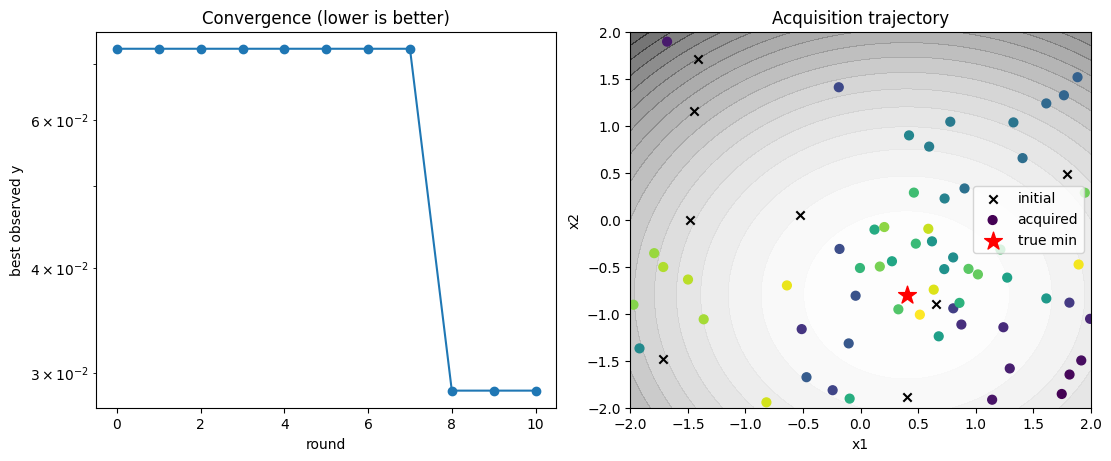

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

axes[0].plot(best_history, "o-")
axes[0].set_xlabel("round"); axes[0].set_ylabel("best observed y")
axes[0].set_yscale("log")
axes[0].set_title("Convergence (lower is better)")

# scatter of acquired points coloured by acquisition order
ax = axes[1]
g = 80
xx, yy = np.meshgrid(np.linspace(-2, 2, g), np.linspace(-2, 2, g))
zz = ((np.column_stack([xx.ravel(), yy.ravel()]) - target) ** 2).sum(axis=1).reshape(xx.shape)
ax.contourf(xx, yy, zz, levels=20, cmap="Greys", alpha=0.6)
ax.scatter(*X0.T, color="k", marker="x", label="initial")
acquired = loop.X_observed[len(X0):]
ax.scatter(*acquired.T, c=np.arange(len(acquired)), cmap="viridis", s=40, label="acquired")
ax.scatter(*target, color="red", marker="*", s=180, label="true min")
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.legend()
ax.set_title("Acquisition trajectory")
plt.show()


## Save / resume the campaign

`loop.save("campaign.json")` writes everything needed to resume — observed data, RNG state, pending batches, history. The trained tree itself is *not* persisted: `ActiveLearner.load(...)` refits it from the data, so the JSON is decoupled from the internal `Tree` layout.


In [6]:
import tempfile, os
with tempfile.TemporaryDirectory() as td:
    path = os.path.join(td, "campaign.json")
    loop.save(path)
    resumed = ActiveLearner.load(
        path, model_factory=factory,
        acquisition=ExpectedImprovement(direction="min"),
        batcher=GreedyMaxMinBatchSelector(diversity_weight=0.4),
    )
    print("resumed:", resumed.X_observed.shape, "obs / best y =", resumed.y_observed.min())


resumed: (68, 2) obs / best y = 0.02854850098255171
